# Tomato Leaf Disease 

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load the dataset

In [2]:
DATA_DIR = r"C:\Users\Raze\projects\p3\Dataset"
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

classes = ds.class_names
n_classes = len(classes)
classes

Found 15951 files belonging to 10 classes.


['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

## Check class balance

In [3]:
import pathlib

data_dir = pathlib.Path(DATA_DIR)
counts = {c: len(list((data_dir / c).glob('*'))) for c in classes}
for c, n in counts.items():
    print(f'{c:50s} {n}')

total = sum(counts.values())
class_weight = {
    i: total / (n_classes * counts[c]) for i, c in enumerate(classes)
}
class_weight

Tomato_Bacterial_spot                              2119
Tomato_Early_blight                                992
Tomato_Late_blight                                 1909
Tomato_Leaf_Mold                                   948
Tomato_Septoria_leaf_spot                          1767
Tomato_Spider_mites_Two_spotted_spider_mite        1672
Tomato__Target_Spot                                1396
Tomato__Tomato_YellowLeaf__Curl_Virus              3201
Tomato__Tomato_mosaic_virus                        365
Tomato_healthy                                     1583


{0: 0.752807928268051,
 1: 1.6080645161290323,
 2: 0.835620743844945,
 3: 1.6827004219409283,
 4: 0.9027730616864742,
 5: 0.9540669856459331,
 6: 1.1426934097421204,
 7: 0.49834426741643234,
 8: 4.37041095890411,
 9: 1.007706885660139}

## Split train/val/test


In [4]:
def get_data_partitions(ds, train_split=0.8, val_split=0.1, shuffle=True, shuffle_size=10000, seed=12):
    ds_size = len(ds)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=seed)
    train_ds = ds.take(train_size)
    remainder = ds.skip(train_size)
    val_ds = remainder.take(val_size)
    test_ds = remainder.skip(val_size)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_data_partitions(ds)
print(f'train batches: {len(train_ds)}, val batches: {len(val_ds)}, test batches: {len(test_ds)}')

train batches: 399, val batches: 49, test batches: 51


In [5]:
train_ds = train_ds.cache("train_cache").shuffle(200).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache("val_cache").prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache("test_cache").prefetch(buffer_size=tf.data.AUTOTUNE)

## Augmentation

`Rescaling(1./255)`

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

## Build the model — frozen MobileNetV2 base + custom head

`include_top=False` drops MobileNetV2's original 1000-class ImageNet head. `base_model.trainable = False` freezes every pretrained weight so stage 1 only trains the new classification head — this is what lets a ~13k-image dataset work well with a network that has millions of parameters, since we're not trying to relearn low-level filters (edges, textures) from scratch.

In [7]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 256, 256, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 256, 256, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 8, 8, 1280)       2257984   
 ional)                                                          
                                                             

## Compile

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

In [9]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2),
    ModelCheckpoint("best_head.weights.h5", monitor="val_accuracy", save_best_only=True, save_weights_only=True),
]

## Stage 1 — train the head, base frozen


In [10]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/12
399/399 [==============================] - 504s 1s/step - loss: 1.0005 - accuracy: 0.6738 - val_loss: 0.4853 - val_accuracy: 0.8374 - lr: 0.0010
Epoch 2/12
399/399 [==============================] - 1096s 2s/step - loss: 0.6408 - accuracy: 0.7872 - val_loss: 0.4449 - val_accuracy: 0.8571 - lr: 0.0010
Epoch 3/12
399/399 [==============================] - 1513s 4s/step - loss: 0.5667 - accuracy: 0.8153 - val_loss: 0.4497 - val_accuracy: 0.8386 - lr: 0.0010
Epoch 4/12
399/399 [==============================] - 784s 2s/step - loss: 0.5315 - accuracy: 0.8263 - val_loss: 0.4387 - val_accuracy: 0.8495 - lr: 0.0010
Epoch 5/12
399/399 [==============================] - 1077s 3s/step - loss: 0.5127 - accuracy: 0.8310 - val_loss: 0.3717 - val_accuracy: 0.8686 - lr: 0.0010
Epoch 6/12
399/399 [==============================] - 3213s 8s/step - loss: 0.4777 - accuracy: 0.8445 - val_loss: 0.3448 - val_accuracy: 0.8756 - lr: 0.0010
Epoch 7/12
399/399 [==============================] - 1867s 

## Stage 2 — fine-tune the top of the base

Now unfreeze the *last* block of MobileNetV2 .

In [14]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 40  # unfreeze roughly the last 40 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

fine_tune_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2),
    ModelCheckpoint("best_finetuned.weights.h5", monitor="val_accuracy", save_best_only=True, save_weights_only=True),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=fine_tune_callbacks,
)

Epoch 1/10


399/399 [==============================] - 596s 1s/step - loss: 0.3789 - accuracy: 0.8744 - val_loss: 0.2955 - val_accuracy: 0.8980 - lr: 1.0000e-05
Epoch 2/10
399/399 [==============================] - 466s 1s/step - loss: 0.3368 - accuracy: 0.8899 - val_loss: 0.3760 - val_accuracy: 0.8642 - lr: 1.0000e-05
Epoch 3/10
399/399 [==============================] - 406s 953ms/step - loss: 0.2845 - accuracy: 0.9071 - val_loss: 0.3225 - val_accuracy: 0.8776 - lr: 1.0000e-05
Epoch 4/10
399/399 [==============================] - 726s 2s/step - loss: 0.2450 - accuracy: 0.9184 - val_loss: 0.2334 - val_accuracy: 0.9190 - lr: 2.0000e-06
Epoch 5/10
399/399 [==============================] - 909s 2s/step - loss: 0.2412 - accuracy: 0.9217 - val_loss: 0.2140 - val_accuracy: 0.9235 - lr: 2.0000e-06
Epoch 6/10
399/399 [==============================] - 563s 1s/step - loss: 0.2275 - accuracy: 0.9248 - val_loss: 0.2168 - val_accuracy: 0.9279 - lr: 2.0000e-06
Epoch 7/10
399/399 [============================

## Evaluate on the held-out test set

In [21]:
test_loss, test_acc = model.evaluate(test_ds)


51/51 [==============================] - 12s 220ms/step - loss: 0.2419 - accuracy: 0.9112


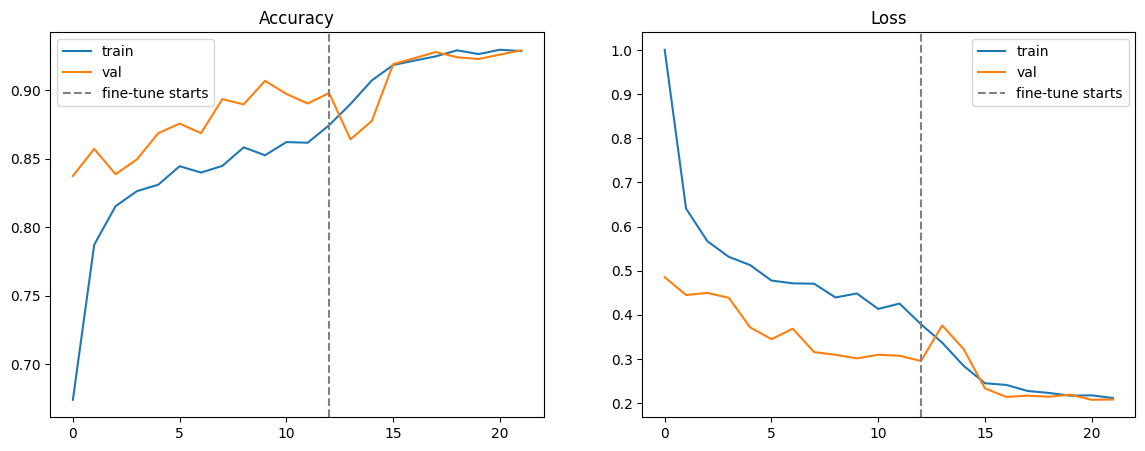

In [16]:
acc = history_head.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history_head.history["val_accuracy"] + history_finetune.history["val_accuracy"]
loss = history_head.history["loss"] + history_finetune.history["loss"]
val_loss = history_head.history["val_loss"] + history_finetune.history["val_loss"]
switch_epoch = len(history_head.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc, label="train")
axes[0].plot(val_acc, label="val")
axes[0].axvline(switch_epoch, color="gray", linestyle="--", label="fine-tune starts")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(loss, label="train")
axes[1].plot(val_loss, label="val")
axes[1].axvline(switch_epoch, color="gray", linestyle="--", label="fine-tune starts")
axes[1].set_title("Loss")
axes[1].legend()

plt.show()

## Sample predictions

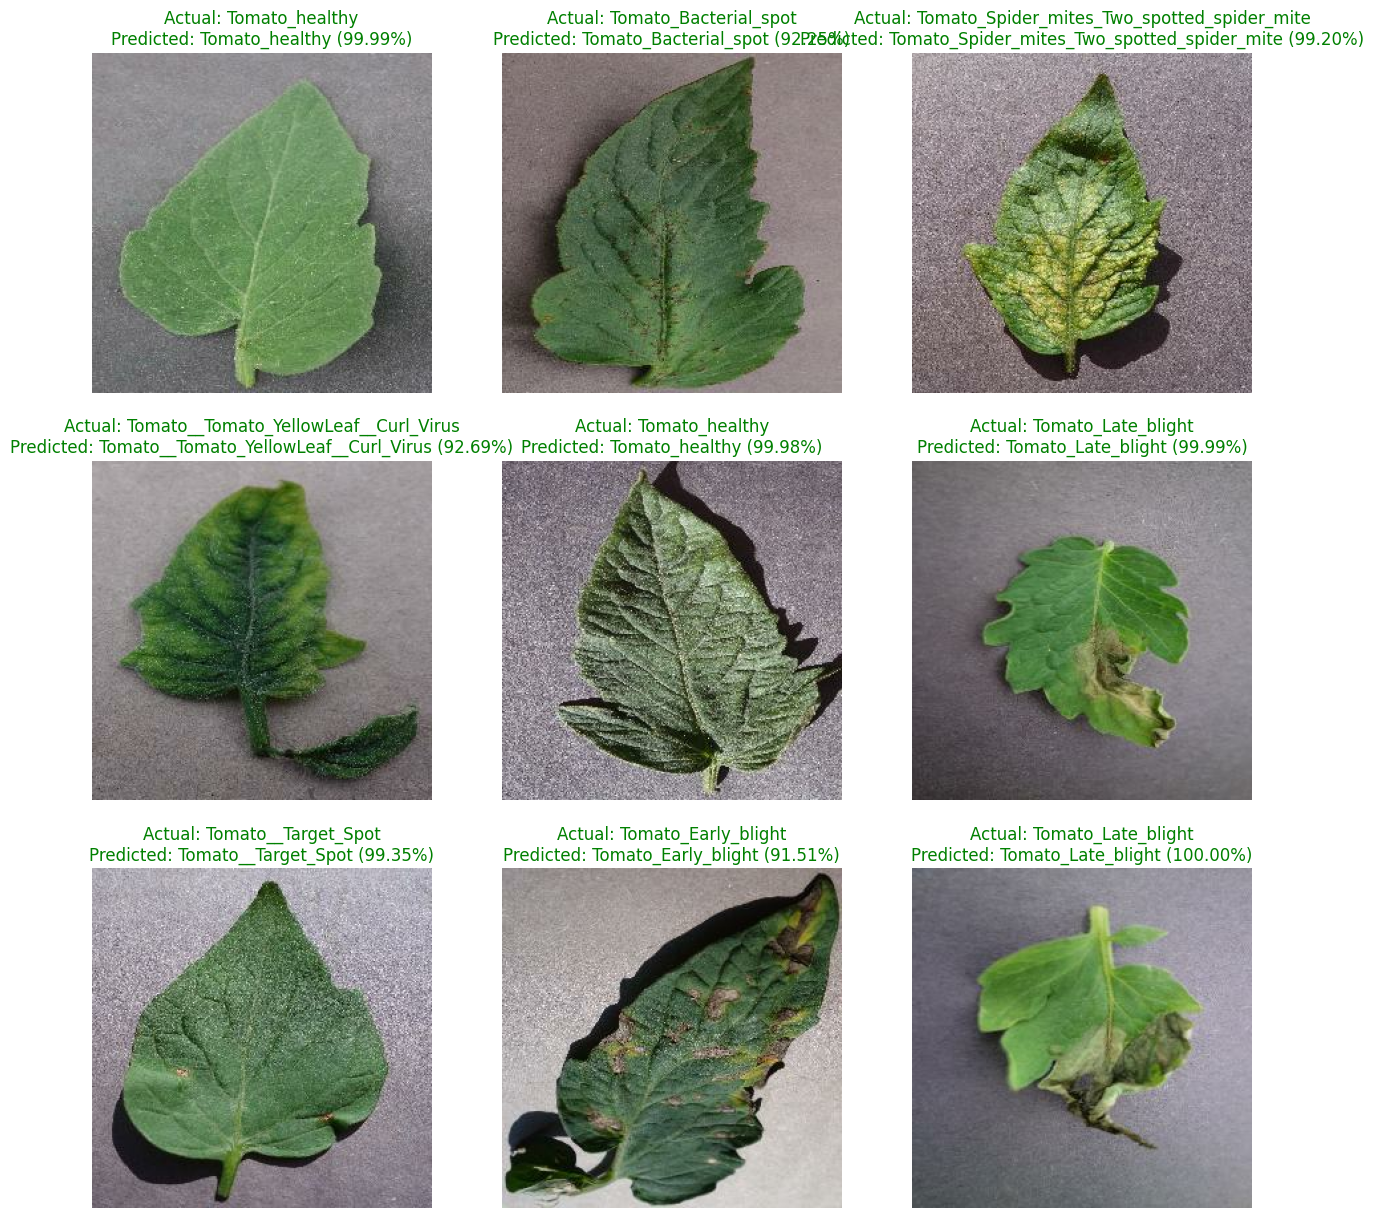

In [17]:
def predict(model, img):
    img_array = tf.expand_dims(img, 0)
    pred = model.predict(img_array, verbose=0)
    pred_class = classes[np.argmax(pred[0])]
    confidence = round(100 * np.max(pred[0]), 2)
    return pred_class, confidence

plt.figure(figsize=(15, 15))
for image_batch, label_batch in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, image_batch[i])
        actual_label = classes[label_batch[i].numpy()]

        color = "green" if predicted_class == actual_label else "red"
        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_class} ({confidence:.2f}%)", color=color)
        plt.axis("off")

## Save the model


In [23]:
model_version = 3
model.save(f"C:/Users/Raze/projects/p3/models/{model_version}")

INFO:tensorflow:Assets written to: C:/Users/Raze/projects/p3/models/3\assets


INFO:tensorflow:Assets written to: C:/Users/Raze/projects/p3/models/3\assets
